# Calcul d'Uplift Potentiel en Conversion

In [19]:
# Hypothèse : Des campagnes ciblées vont améliorer le taux de conversion.

## Charger les Données

In [15]:
# Partons avec les imports

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Créer un dataframe

path = r'C:\Users\shree\Documents\Professional\Job Search 25-26\Interview Prep\PSG\Case Study - PSG\Case Study - PSG\Work\Data\Analysis'
file = 'conversion_uplift.csv'

uplift_calc = pd.read_csv(r'{}\{}'.format(path, file), sep = '\t', encoding = 'utf-16')
uplift_calc.head()

,Country (World Population Data.Csv),Supporteurs,Clients,Client or Subscriber,Prospects,Opt-in Prospects,Opt-Out Prospects,Opt-in Clients & Subscribers,Opt-out Clients & Subscribers
0,South Korea,"58,221","7,676","7,714","50,507","27,318","23,189","3,682","4,032"
1,India,"36,833",169,169,"36,664","23,482","13,182",51,118
2,Japan,"15,884","1,644","1,666","14,218","6,096","8,122",651,"1,015"
3,China,"12,902",703,707,"12,195","7,699","4,496",358,349
4,Nigeria,"12,013",16,16,"11,997","9,776","2,221",5,11


In [7]:
# Vérifier le type de données

uplift_calc.dtypes

Country (World Population Data.Csv)    object
Supporteurs                            object
Clients                                object
Client or Subscriber                   object
Prospects                              object
Opt-in Prospects                       object
Opt-Out Prospects                      object
Opt-in Clients & Subscribers           object
Opt-out Clients & Subscribers          object
dtype: object

In [14]:
# Transformer tous les colonnes sauf la première en int64
# Renommer première colonne comme 'country'
# supprimer dernière ligne 'Grand Total'

column_names = ['Supporteurs', 'Clients', 'Client or Subscriber', 'Prospects', 'Opt-in Prospects', 'Opt-Out Prospects', 'Opt-in Clients & Subscribers', 'Opt-out Clients & Subscribers']

for col in column_names:
    uplift_calc[col] = uplift_calc[col].str.replace(',', '')
    uplift_calc[col] = uplift_calc[col].astype('int64')

uplift_calc = uplift_calc.rename(columns = {'Country (World Population Data.Csv)':'Country'})
uplift_calc = uplift_calc[uplift_calc['Country'] != 'Grand Total']

uplift_calc.head()

,Country,Supporteurs,Clients,Client or Subscriber,Prospects,Opt-in Prospects,Opt-Out Prospects,Opt-in Clients & Subscribers,Opt-out Clients & Subscribers
0,South Korea,58221,7676,7714,50507,27318,23189,3682,4032
1,India,36833,169,169,36664,23482,13182,51,118
2,Japan,15884,1644,1666,14218,6096,8122,651,1015
3,China,12902,703,707,12195,7699,4496,358,349
4,Nigeria,12013,16,16,11997,9776,2221,5,11


## Test Statistique

In [20]:
# Hypothèses :
# H0 - Les différences en conversions vers clients sont dues aux variations aléatoires.
# H1 - Les différences en conversions vers clients ne sont pas dues aux variations aléatoires.

# Considérer uniquement des pays avec au moins 1 client ou abonné
# Sélectionner Clients comme succès, Prospects comme échecs

chi2 = uplift_calc[uplift_calc['Clients'] > 0][['Clients', 'Prospects']]

# Convertir en table test numpy

test_table = chi2.to_numpy(dtype = np.int64)

In [21]:
# Mener Test Chi2 avec alpha 0,05

alpha = 0.05

Chi_statistic, p_value, dof, expected_table = stats.chi2_contingency(test_table)

if p_value <= alpha:
    print("La valeur-P est inférieure de 0,05. Donc, l'hypothèse null est rejeté.")
else:
    print("La valeur-P est supérieure de 0,05. Donc, l'hypothèse null ne peux pas être rejeté.")

print("Chi2 Statistic:",Chi_statistic)
print("Valeur P:", p_value)
print("Degrees of Freedom", dof)

La valeur-P est inférieure de 0,05. Donc, l'hypothèse null est rejeté.
Chi2 Statistic: 16392.92260896846
Valeur P: 0.0
Degrees of Freedom 64


In [22]:
# Avec confirmation de différences réels entre pays en taux de conversion, on peut maintenant calculer l'Uplift Potentiel

## Calcul du Uplift

In [29]:
# Segmentation d'audiences :
#     Certains - déjà clients ou abonnés avec opt-in PSG.
#     Pesuadables - prospects avec opt-in PSG.
#     Cause Perdus - prospects sans opt-in PSG.
#     Ne pas déranger - déjà clients ou abonnés sans opt-in PSG.

# Calcul du Uplift : Assumer une amélioration modeste de 30 %
#     Taux de conversion nouveau = 1,3 * taux de conversion actuel
#     Uplift Potentiel = taux de conversion nouveau - taux de conversion actuel.

# Calculer taux de conversions actuel des supporteurs avec opt-in (total de prospects, clients, et abonnés avec opt-in)

uplift_calc['pop_conv_rate_actual'] = uplift_calc['Opt-in Clients & Subscribers'] / (uplift_calc['Opt-in Clients & Subscribers'] + uplift_calc['Opt-in Prospects'])

# Calculer taux de conversions avec intervention

uplift_calc['pop_conv_rate_new'] = uplift_calc['pop_conv_rate_actual'] * 1.3

# calculer uplift

uplift_calc['Uplift Potential'] = round(uplift_calc['pop_conv_rate_new'] - uplift_calc['pop_conv_rate_actual'], 2)

# calculer clients ajoutés potentiels

uplift_calc['Added Client or Subscriber'] = round(uplift_calc['Uplift Potential'] * uplift_calc['Opt-in Prospects'], 0)

# voir le database avec des clients additionnels potentiels

uplift_results = uplift_calc[['Country', 'Client or Subscriber', 'Opt-in Prospects', 'Added Client or Subscriber', 'Uplift Potential']]

uplift_results.sort_values(by = 'Added Client or Subscriber', ascending = False)

,Country,Client or Subscriber,Opt-in Prospects,Added Client or Subscriber,Uplift Potential
0,South Korea,7714,27318,1093.0,0.04
2,Japan,1666,6096,183.0,0.03
3,China,707,7699,77.0,0.01
25,Georgia,283,966,29.0,0.03
15,Singapore,304,1797,18.0,0.01
...,...,...,...,...,...
80,Equatorial Guinea,2,33,0.0,0.01
81,Seychelles,0,24,0.0,0.00
82,Eritrea,0,21,0.0,0.00
83,Timor-Leste,0,10,0.0,0.00


## Visualiser les Résultats

In [37]:
# Graphiques choisis : barre groupé avec double axes

# Préparer les données, isoler les pays avec plus de 10 clients ou abonnés potentiellement ajoutés

uplift_graph = uplift_results[uplift_results['Added Client or Subscriber'] > 10]

<function matplotlib.pyplot.show(close=None, block=None)>

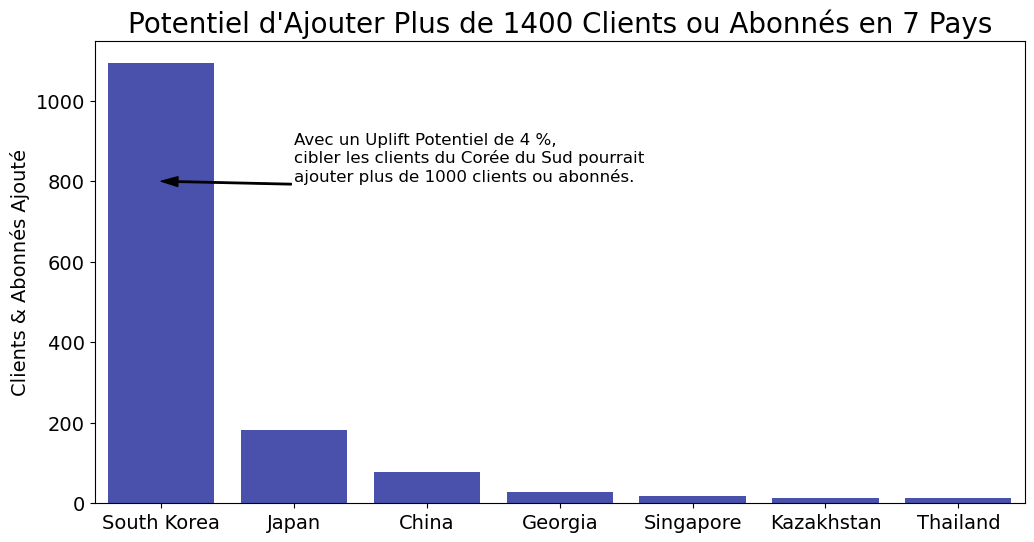

In [87]:
plt.figure(figsize = (12, 6))

sns.barplot(data = uplift_graph.sort_values(by = 'Added Client or Subscriber', ascending = False), x = 'Country', y = 'Added Client or Subscriber',
           color = '#3943bc')
plt.xlabel('')
plt.ylabel('Clients & Abonnés Ajouté', fontsize = 14)
plt.tick_params(which = 'major', labelsize = 14)
plt.annotate(text = "Avec un Uplift Potentiel de 4 %,\ncibler les clients du Corée du Sud pourrait \najouter plus de 1000 clients ou abonnés.",
             xy = ('South Korea', 800), xytext = ('Japan', 800), fontsize = 12, arrowprops = dict(width = 1, facecolor = 'black', headwidth = 7))
plt.title(label = "Potentiel d'Ajouter Plus de 1400 Clients ou Abonnés en 7 Pays", fontsize = 20)

plt.savefig(r'C:\Users\shree\Documents\Professional\Job Search 25-26\Interview Prep\PSG\Case Study - PSG\Case Study - PSG\Work\Visualisations\Uplift Conversions.png')
plt.show